# Segment Contribution Analysis


## Load data

1. Aggregate transaction-level data.
To make the analysis more meaningful, I introduced controlled perturbations to simulate noticeable growth patterns.

2. Select a target merchant and benchmark key business metrics (e.g., transaction amount, transaction count) against peer merchants within the same category.

In [1]:
import pandas as pd
import numpy as np
import etl
from exhaustive_segment_search import exhaustive_eval
from config import DIMENSION_COLS
from helper import plot_waterfall

In [2]:
TARGET_MERCHANTS = "fraud_Kilback LLC"
target_col = "amt_growth_ctc_diff"
dim_cols = DIMENSION_COLS

df_combined = etl.load_rca_data(TARGET_MERCHANTS)

File exists, loading data from /Users/yanxinye/github/competency-intelligence/src/segment_analysis/etl/rca_fraud_Kilback LLC.csv...


## Segment-Level Decomposition

### Option1: Exhaustive Search of All Dimension Interactions

An intuitive approach to identifying segments that explain the gap between a target merchant and its peers is to compute metrics across all combinations of dimension columns (i.e., k-way interactions).

In [3]:
sorted_res = exhaustive_eval(df_combined, target_col, dim_cols=dim_cols)

total = df_combined[target_col].sum()
print(f"The total growth difference is: {total:.2%}")
print("Top segment drivers:\n")
for i, (k, v) in enumerate(sorted_res[:20], 1):
    print(f"{i:>2}. {k:<50} | {v:>8.2%} | contribution: {v/total:>6.2%}")

The total growth difference is: 25.87%
Top segment drivers:

 1. gender = F                                         |   18.82% | contribution: 72.73%
 2. generation = Millennial, market = South            |   14.53% | contribution: 56.17%
 3. generation = Gen X                                 |   14.10% | contribution: 54.49%
 4. market = South                                     |   14.01% | contribution: 54.16%
 5. category = food_dining                             |   13.58% | contribution: 52.49%
 6. category = grocery_pos                             |   12.29% | contribution: 47.51%
 7. generation = Millennial, category = grocery_pos, market = South |   12.24% | contribution: 47.29%
 8. generation = Millennial                            |   11.14% | contribution: 43.07%
 9. generation = Millennial, gender = F, category = grocery_pos, market = South |    9.83% | contribution: 38.00%
10. generation = Gen X, market = West                  |    9.68% | contribution: 37.42%
11. gender 


This results in **O(2ⁿ)** complexity, with computational cost growing exponentially as the number of dimensions increases.

To maintain tractability, we can cap the interaction depth (e.g., *k ≤ 3*), trading off computational efficiency against the ability to capture higher-order interactions.

### Option2: Tree search

In [4]:
from tree_search import TreeForest



forest = TreeForest(
    df_combined,
    target_col,
    DIMENSION_COLS,
    n_trees=3,
    max_coverage=0.2,
    max_depth=4,
)
forest.construct_forest()







Learned key drivers from the forest:
Peer growth contribution: 94.52%
Target growth contribution: 120.39%

Key drivers and their contributions:
Peer Benchmark                 |   94.52% | contribution: 78.51%
generation = Millennial|gender = F|category = grocery_pos|market = South |    7.27% | contribution:  6.04%
gender = F|category = food_dining|state = IN|market = Midwest |    4.76% | contribution:  3.95%
generation = Gen X|category = grocery_pos|state = CA|market = West |    9.23% | contribution:  7.67%
Other                          |    4.62% | contribution:  3.83%
Target (fraud_Kilback LLC)     |  120.39% | contribution: 100.00%


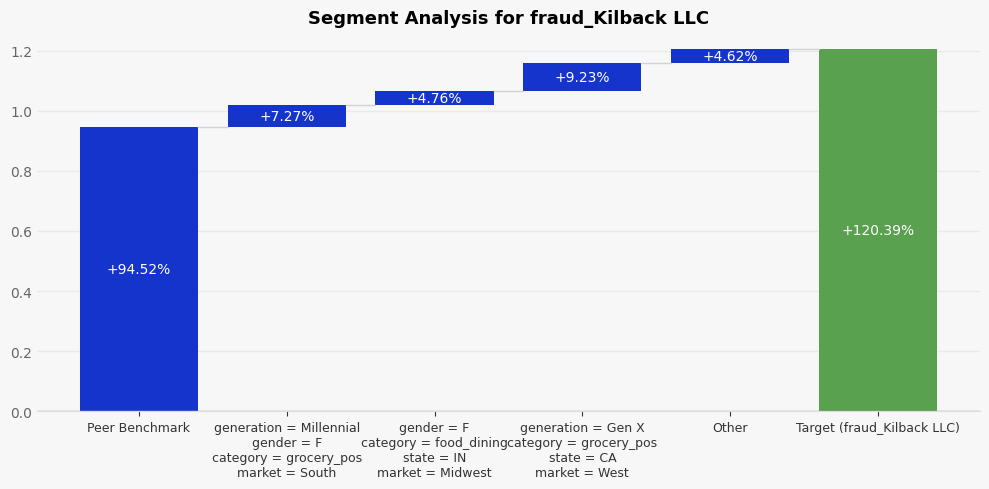

In [5]:
print("\nLearned key drivers from the forest:")
dim, val = forest.collect_key_drivers()
peer_score = df_combined["amt_growth_ctc_peer"].sum()
target_score = df_combined["amt_growth_ctc"].sum()
print(f"Peer growth contribution: {peer_score:.2%}")
print(f"Target growth contribution: {target_score:.2%}")
dim = ["Peer Benchmark"] + dim + [f"Target ({TARGET_MERCHANTS})"]
val = [peer_score] + val + [target_score]
print("\nKey drivers and their contributions:")
for d, v in zip(dim, val):
    print(f"{d:<30} | {v:>8.2%} | contribution: {v/target_score:>6.2%}")

plot_waterfall(dim, val, title=f"Segment Analysis for {TARGET_MERCHANTS}")